# SVM

Support Vector Machines (SVMs) are powerful and flexible supervised machine learning algorithms that can be used for both classification and regression. However, they are generally more commonly used for classification problems.

SVMs were first introduced in the 1960s and were later refined in the 1990s. Compared with other machine learning algorithms, SVMs use a unique approach to model implementation. More recently, these algorithms have become increasingly popular due to their ability to handle multiple continuous and categorical variables.


## Part 1

### Make a dataset

In [1]:
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#### Dataset 1

In [ ]:
x_train1=np.array(1000*random.rand(1000))
y_train1=np.array(1000*random.rand(1000))


# make dataset 
df1=pd.DataFrame({"x_train1":x_train1 ,"y_train1":y_train1})
df1["y_line1"]=df1["x_train1"]+100

# define formula for determine group
def Group(x_train1,y_line1,y_train1):
    
    y_line1=x_train1+100
    
    if (y_train1 <= y_line1):
        return 0 
    
    return 1


df1["class"]= df1.apply(lambda row: Group(row['x_train1'],row['y_line1'], row['y_train1']), axis=1)


In [3]:
df1.head()

,x_train1,y_train1,y_line1,class
0,784.664143,668.079486,884.664143,0
1,948.512868,682.480912,1048.512868,0
2,2.111468,809.893706,102.111468,1
3,101.011540,294.192804,201.011540,1
4,117.420599,532.323071,217.420599,1


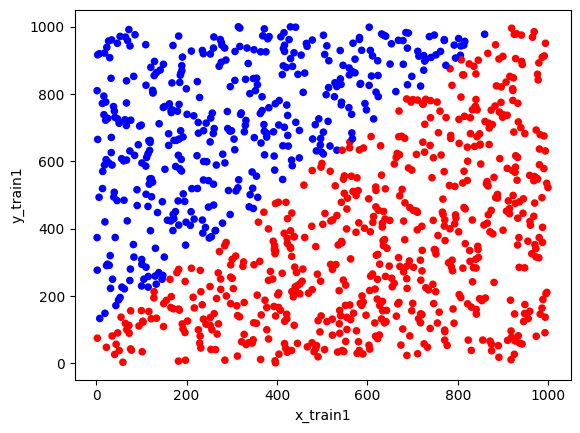

In [4]:
colors = {0: 'red', 1: 'blue'}

df1.plot.scatter("x_train1", "y_train1",c=df1['class'].apply(lambda val: colors[val]))

#plt.plot(df1["x_train"],df1["y_line"],label='Line',color="Red")
#plt.title(" Simple")
#plt.legend()
plt.show()

#### Dataset 2

In [5]:
x_train2=np.array(1000*random.rand(1000))
y_train2=np.array(1000*random.rand(1000))


# make dataset 
df2=pd.DataFrame({"x_train2":x_train2 ,"y_train2":y_train2})
oval = Ellipse((500, 500), 800, 500, angle=20,edgecolor='red', fill=False, linewidth=2)

# define formula for determine group
def Group(x_train2,y_train2):
    
    if  oval.contains_point([x_train2,y_train2]):
        return 0
    
    return 1


df2["class"]= df2.apply(lambda row: Group(row['x_train2'], row['y_train2']), axis=1)





In [6]:
df2.head()

,x_train2,y_train2,class
0,610.717092,578.982952,0
1,70.904630,68.807514,1
2,885.196547,988.769241,1
3,904.148738,953.703614,1
4,526.456955,78.187962,1


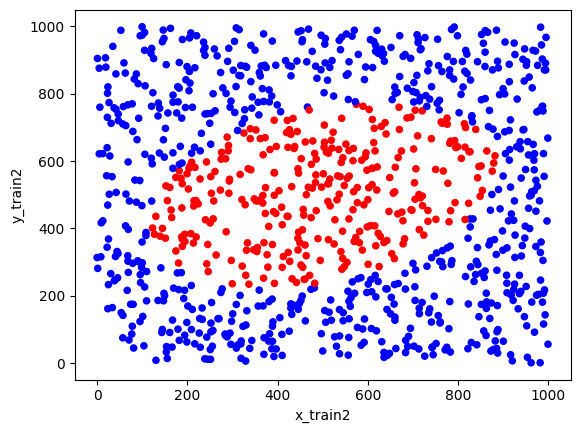

In [7]:
colors = {0: 'red', 1: 'blue'}
df2.plot.scatter("x_train2", "y_train2",c=df2['class'].apply(lambda val: colors[val]))

#ax.add_artist(oval)
#plt.legend()
plt.show()

#### Dataset3


In [8]:
x_train3=np.array(1000*random.rand(1000))
y_train3=np.array(1000*random.rand(1000))


# make dataset 
df3=pd.DataFrame({"x_train3":x_train3 ,"y_train3":y_train3})

# define formula for determine group
df3["class"]= df3.apply(lambda row: random.choice([0, 1]), axis=1)

In [9]:
df3.head()

,x_train3,y_train3,class
0,812.990270,480.987912,1
1,408.922409,930.694685,1
2,715.923659,115.469749,0
3,863.822278,899.966672,1
4,537.772002,945.739171,0


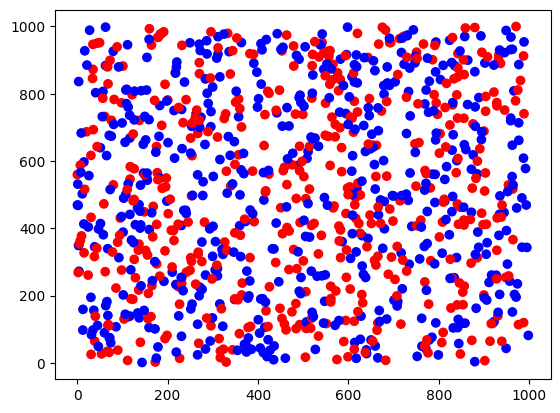

In [10]:
# Define the colors for each value
colors = {0: 'red', 1: 'blue'}
plt.scatter(df3['x_train3'], df3['y_train3'], c=df3['class'].apply(lambda val: colors[val]))
plt.show()

### SVM

In [11]:
#from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#### Dataset 1

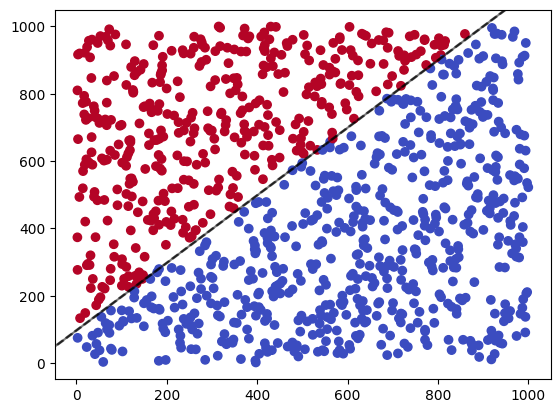

In [14]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train1, y_train1))
y = np.array(df1["class"])

# Train the SVM model
clf = svm.SVC(kernel='linear')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train1, y_train1, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)


# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.show()

In [15]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.995 0.995 1.    1.    1.   ]
Mean score: 0.998


For the first dataset, since the data could be separated using a line, the accuracy was close to 100%. Cross-validation was used to measure the accuracy.


#### Dataset 2

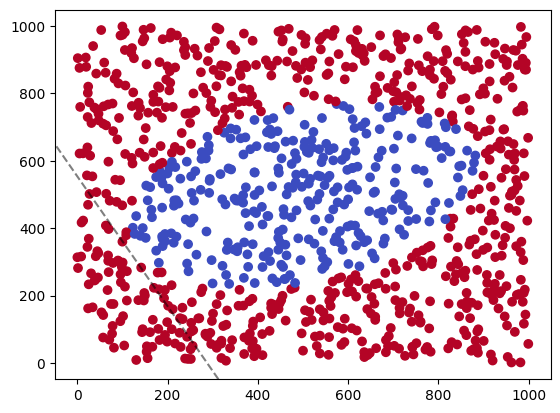

In [16]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train2, y_train2))
y = np.array(df2["class"])

# Train the SVM model
clf = svm.SVC(kernel='linear')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train2, y_train2, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)


# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.show()

In [17]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.685 0.69  0.69  0.69  0.69 ]
Mean score: 0.689


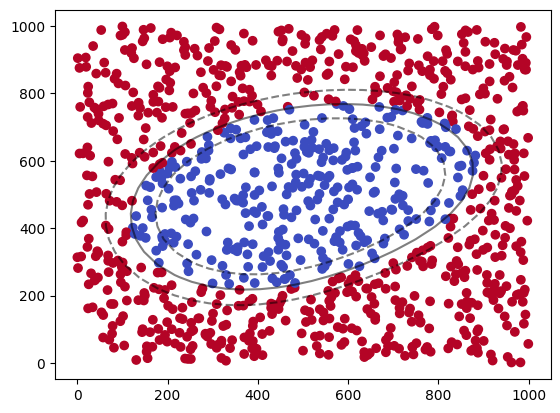

In [18]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train2, y_train2))
y = np.array(df2["class"])

# Train the SVM model
clf = svm.SVC(kernel='rbf')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train2, y_train2, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [19]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.99  0.97  0.98  0.975 0.98 ]
Mean score: 0.9789999999999999


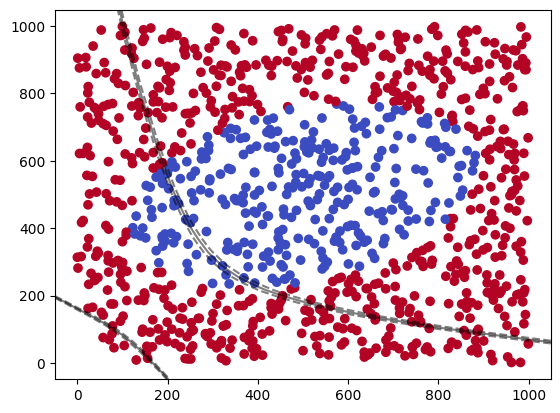

In [20]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train2, y_train2))
y = np.array(df2["class"])

# Train the SVM model
clf = svm.SVC(kernel='sigmoid')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train2, y_train2, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [21]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.475 0.46  0.475 0.45  0.46 ]
Mean score: 0.4640000000000001


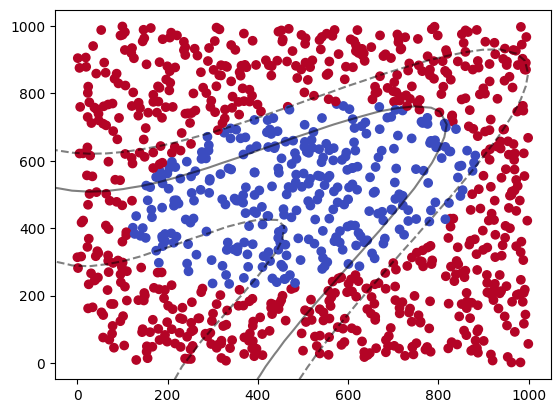

In [22]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train2, y_train2))
y = np.array(df2["class"])

# Train the SVM model
clf = svm.SVC(kernel='poly')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train2, y_train2, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [23]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.78  0.75  0.795 0.745 0.75 ]
Mean score: 0.764


For the second dataset, since the classes are separated in an elliptical pattern, the linear kernel does not perform well. The RBF kernel, which can separate the data using a nonlinear closed boundary, was therefore more suitable than the other kernels for this dataset.


#### Dataset 3

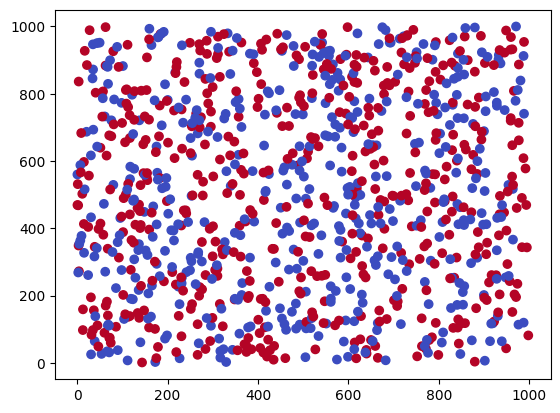

In [24]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train3, y_train3))
y = np.array(df3["class"])

# Train the SVM model
clf = svm.SVC(kernel='linear')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train3, y_train3, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [25]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.485 0.525 0.525 0.52  0.52 ]
Mean score: 0.515


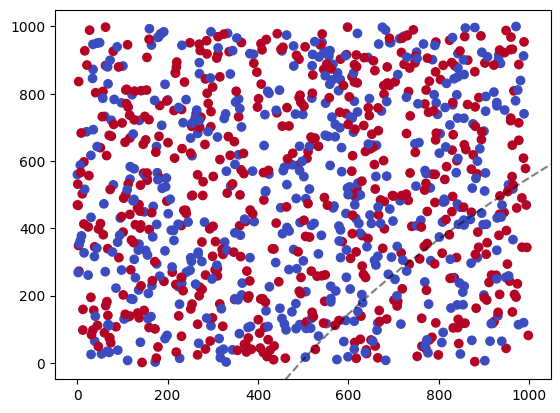

In [26]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train3, y_train3))
y = np.array(df3["class"])

# Train the SVM model
clf = svm.SVC(kernel='poly')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train3, y_train3, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [27]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.525 0.525 0.525 0.52  0.52 ]
Mean score: 0.523


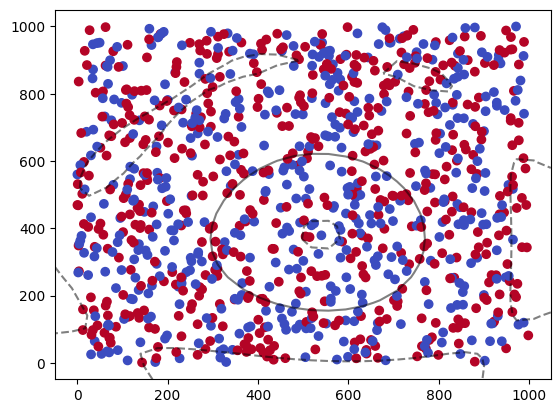

In [28]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train3, y_train3))
y = np.array(df3["class"])

# Train the SVM model
clf = svm.SVC(kernel='rbf')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train3, y_train3, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [29]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.485 0.5   0.48  0.525 0.51 ]
Mean score: 0.5


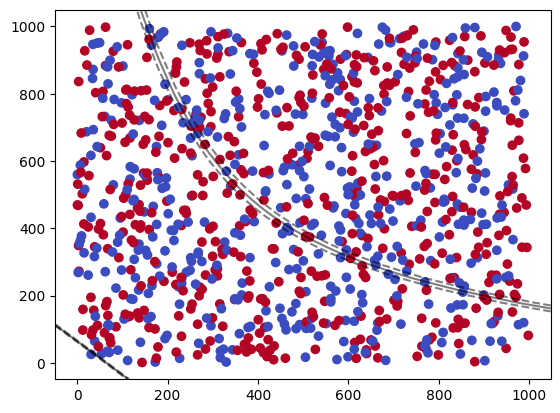

In [30]:
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# Convert the input data and class labels to numpy arrays
X = list(zip(x_train3, y_train3))
y = np.array(df3["class"])

# Train the SVM model
clf = svm.SVC(kernel='sigmoid')
clf.fit(X, y)

# Plot the data and the decision boundary
plt.scatter(x_train3, y_train3, c=y, cmap='coolwarm')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
#ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,linewidth=1, facecolors='none', edgecolors='k')
plt.show()

In [31]:
# Assuming you have already trained your SVM model
scores = cross_val_score(clf, X, y, cv=5)  # Perform 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.55  0.455 0.44  0.5   0.49 ]
Mean score: 0.487


For the final dataset, the classes were not easily separable, resulting in a substantially higher model error compared with the previous cases. Among all the kernels, the RBF kernel achieved the best results.

Conclusion: The kernel that provides the highest accuracy depends on the type and structure of the data.


## Part 2

In [3]:
# Import the necessary libraries:

import numpy as np
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC



C:\Users\PC\AppData\Local\Programs\Python\Python39\lib\site-packages\requests\__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.8) or chardet (5.1.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


In [33]:
# Load the MNIST dataset using keras:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize the data:

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


# Use only 1000 data points for training and testing:

X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=1000, stratify=y_train)
X_test, _, y_test, _ = train_test_split(X_test, y_test, train_size=1000, stratify=y_test)


# Train the SVM model:

model = SVC(kernel='rbf')
model.fit(X_train, y_train)



# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=10)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)

Cross-validation scores: [0.86 0.94 0.9  0.86 0.92 0.93 0.9  0.9  0.89 0.91] 
Mean score:  0.901


In [34]:
# Load the MNIST dataset using keras:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize the data:

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


# Use only 1000 data points for training and testing:

X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=1000, stratify=y_train)
X_test, _, y_test, _ = train_test_split(X_test, y_test, train_size=1000, stratify=y_test)


# Train the SVM model:

model = SVC(kernel='linear')
model.fit(X_train, y_train)



# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=10)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)

Cross-validation scores: [0.87 0.89 0.9  0.87 0.83 0.9  0.91 0.87 0.91 0.84] 
Mean score:  0.8790000000000001


In [35]:
# Load the MNIST dataset using keras:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Reshape and normalize the data:

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


# Use only 1000 data points for training and testing:

X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=1000, stratify=y_train)
X_test, _, y_test, _ = train_test_split(X_test, y_test, train_size=1000, stratify=y_test)


# Train the SVM model:

model = SVC(kernel='sigmoid')
model.fit(X_train, y_train)



# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=10)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)

Cross-validation scores: [0.81 0.82 0.81 0.86 0.84 0.83 0.87 0.87 0.91 0.84] 
Mean score:  0.8460000000000001


In [5]:
# Load the MNIST dataset using keras:
(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Reshape and normalize the data:

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


# Use only 1000 data points for training and testing:
X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=1000, stratify=y_train)
X_test, _, y_test, _ = train_test_split(X_test, y_test, train_size=1000, stratify=y_test)

# Train the SVM model:

model = SVC(kernel='poly')
model.fit(X_train, y_train)

# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=10)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)

Cross-validation scores: [0.88 0.87 0.86 0.85 0.82 0.85 0.85 0.89 0.82 0.83] 
Mean score:  0.852


In this section, we used the same MNIST dataset from the previous section to provide a better comparison between the two models.

In this case, the highest accuracy was also achieved using the RBF kernel, with an accuracy of approximately 90%. The neural network model implemented earlier achieved an accuracy of 85%. This indicates that the SVM model is more suitable for this dataset. However, it should be noted that the performance of the neural network could potentially be improved by adjusting the number of epochs and layers, which would require experimentation and trial and error. Nevertheless, the RBF kernel again achieved the highest accuracy among the SVM kernels.

Conclusion: Under the default settings, the SVM model provides better results and higher accuracy than the neural network model.


## Part 3

In [6]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

In [7]:
# Define a function to load the images and labels:
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = filename.split('_')[0]  # Extract the label from the filename
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read the image as grayscale
        img = cv2.resize(img, (28, 28))  # Resize the image to 28x28 pixels
        img = img.astype('float32') / 255  # Normalize the pixel values
        img = img.reshape(-1)  # Flatten the image into a one-dimensional array
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


# Load the images and labels from the folders:
X, y = load_images_from_folder('E:/IUST/year 4/8/AL/Code/SVM/SVM/2')

# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Train the SVM model:

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=3)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)


Cross-validation scores: [0. 0. 0.] 
Mean score:  0.0


In [8]:
# Define a function to load the images and labels:
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = filename.split('_')[0]  # Extract the label from the filename
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read the image as grayscale
        img = cv2.resize(img, (28, 28))  # Resize the image to 28x28 pixels
        img = img.astype('float32') / 255  # Normalize the pixel values
        img = img.reshape(-1)  # Flatten the image into a one-dimensional array
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


# Load the images and labels from the folders:
X, y = load_images_from_folder('E:/IUST/year 4/8/AL/Code/SVM/SVM/2')

# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Train the SVM model:

model = SVC(kernel='poly')
model.fit(X_train, y_train)

# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=3)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)


Cross-validation scores: [0. 0. 0.] 
Mean score:  0.0


In [9]:
# Define a function to load the images and labels:
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = filename.split('_')[0]  # Extract the label from the filename
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read the image as grayscale
        img = cv2.resize(img, (28, 28))  # Resize the image to 28x28 pixels
        img = img.astype('float32') / 255  # Normalize the pixel values
        img = img.reshape(-1)  # Flatten the image into a one-dimensional array
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


# Load the images and labels from the folders:
X, y = load_images_from_folder('E:/IUST/year 4/8/AL/Code/SVM/SVM/2')

# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Train the SVM model:

model = SVC(kernel='sigmoid')
model.fit(X_train, y_train)

# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=3)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)


Cross-validation scores: [0. 0. 0.] 
Mean score:  0.0


In [11]:
# Define a function to load the images and labels:
def load_images_from_folder(folder):
    images = []
    labels = []
    for filename in os.listdir(folder):
        label = filename.split('_')[0]  # Extract the label from the filename
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read the image as grayscale
        img = cv2.resize(img, (28, 28))  # Resize the image to 28x28 pixels
        img = img.astype('float32') / 255  # Normalize the pixel values
        img = img.reshape(-1)  # Flatten the image into a one-dimensional array
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)


# Load the images and labels from the folders:
X, y = load_images_from_folder('E:/IUST/year 4/8/AL/Code/SVM/SVM/2')

# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Train the SVM model:

model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Use cross-validation to calculate the score
scores = cross_val_score(model, X_train, y_train, cv=3)
accurancy= scores.mean()
# Print the mean score and standard deviation
print('Cross-validation scores:', scores,
     "\nMean score: ",accurancy)


Cross-validation scores: [0. 0. 0.] 
Mean score:  0.0


In this section, we imported the provided dataset, which contained images of license plate digits, and classified them using the SVM model. We then evaluated the model using different kernels, among which the best-performing kernel was the RBF kernel.
